# Offline Knowledge Distillation — Vision-Language (Colab)

**Phase 1** : Générer les logits du teacher 7B  
**Phase 2** : Entraîner le student 2B avec les logits + images re-processées

---

## 0. Setup & Installation

In [3]:
!nvidia-smi

Mon Mar  9 16:18:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   65C    P0             28W /   70W |     107MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install -q torch transformers datasets accelerate bitsandbytes tqdm numpy
!pip install -q qwen-vl-utils Pillow

## 1. Configuration

Modifie les paramètres ici avant de lancer.

In [ ]:
# ============================================================
# CONFIGURATION — modifie ici
# ============================================================

# Modèles
TEACHER_MODEL = "letxbe/qwen2-7b-BoundingDocs-rephrased"
STUDENT_MODEL = "Qwen/Qwen2-VL-2B-Instruct"

# Dataset
DATASET_NAME = "letxbe/BoundingDocs"
MAX_SAMPLES = 10  # Pour un test rapide. Mettre None pour tout le dataset.

# Chemins
LOGITS_DIR = "/content/cached_logits_vl"
OUTPUT_DIR = "/content/distilled_docexplainer"

# Teacher
LOAD_IN_4BIT = True  # True pour T4 (16 Go VRAM), False si A100

# Student — hyperparamètres d'entraînement
EPOCHS = 1
BATCH_SIZE = 1
GRADIENT_ACCUMULATION_STEPS = 4
LEARNING_RATE = 1e-5
TEMPERATURE = 2.0
ALPHA = 0.5  # 0.0 = fine-tuning pur, 1.0 = distillation pure, 0.5 = combiné
SAVE_EVERY = 500

# Constantes internes
TOP_K_LOGITS = 64
MAX_SEQ_LEN = 1024 

# T4 ne supporte pas bfloat16 nativement
import torch
STUDENT_DTYPE = torch.float16 if not torch.cuda.is_bf16_supported() else torch.bfloat16
print(f"Student dtype: {STUDENT_DTYPE}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

Student dtype: torch.bfloat16
GPU: Tesla T4


## 2. Imports & fonctions communes

In [4]:
import json
import os
import numpy as np
from pathlib import Path
from typing import Optional

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoProcessor,
    AutoModelForImageTextToText,
    BitsAndBytesConfig,
    get_cosine_schedule_with_warmup,
)
from datasets import load_dataset
from tqdm.auto import tqdm

from qwen_vl_utils import process_vision_info

print("Imports OK")

Imports OK


In [5]:
# ============================================================
# Prompts du teacher (format attendu par le modèle fine-tuné)
# ============================================================

SYSTEM_MESSAGE = (
    "You are a Vision Language Model specialized in extracting information "
    "from document images.\n"
    "Your task is to analyze the provided document image and extract relevant "
    "information accurately.\n"
    "Documents may contain text, tables, forms, and structured or unstructured data.\n"
    "Ensure responses are precise and concise, without additional explanations "
    "unless required for clarity."
)

TEMPLATE_PROMPT = (
    '<starttask>\n'
    'Answer the following question about the document:\n'
    'Question: "{QUESTION}"\n'
    'Answer completing the following format:\n'
    "'''json\n"
    '{{"value": ""}}\n'
    "'''\n"
    '<endtask>'
)

In [6]:
def format_boundingdocs_sample(sample: dict) -> Optional[dict]:
    """
    Transforme un sample brut du dataset BoundingDocs
    en format chat Qwen2-VL (messages + answer).
    Gère les deux formats de Q&A : liste ou dict.
    Retourne None si le sample est invalide.
    """
    try:
        qa_data = (
            json.loads(sample["Q&A"])
            if isinstance(sample["Q&A"], str)
            else sample["Q&A"]
        )
    except (json.JSONDecodeError, KeyError):
        return None

    if not qa_data:
        return None

    # --- Gérer les deux formats possibles ---
    if isinstance(qa_data, list):
        # Format liste : [{"question": ..., "answers": [...]}]
        qa = qa_data[0]
    elif isinstance(qa_data, dict):
        # Format dict : {"DOC_ID": {"question": ..., "answers": [...]}}
        first_key = next(iter(qa_data))
        qa = qa_data[first_key]
    else:
        return None

    question = qa.get("rephrased_question") or qa.get("question", "")
    if not question:
        return None

    answers = qa.get("answers", [])
    if not answers:
        return None

    answer_value = answers[0].get("value", "")
    if not answer_value:
        return None

    image = None
    if sample.get("doc_images") and len(sample["doc_images"]) > 0:
        image = sample["doc_images"][0]

    if image is None:
        return None

    prompt = TEMPLATE_PROMPT.format(QUESTION=question)

    messages = [
        {
            "role": "system",
            "content": [{"type": "text", "text": SYSTEM_MESSAGE}],
        },
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": prompt},
            ],
        },
    ]

    return {
        "messages": messages,
        "answer": json.dumps({"value": answer_value}),
        "answer_raw": answer_value,
    }

## 3. Phase 1 — Générer les logits du teacher

Le teacher fait de l'inférence sample par sample. On sauvegarde :
- les top-64 logits par position
- les `input_ids` (tokens)
- le `dataset_index` (pour retrouver l'image en Phase 2)

In [7]:
# --- Charger le processor (depuis le modèle base, comme la model card l'indique) ---
print("Loading processor from Qwen/Qwen2-VL-7B-Instruct...")
min_pixels = 256 * 28 * 28
max_pixels = 512 * 28 * 28
teacher_processor = AutoProcessor.from_pretrained(
    "Qwen/Qwen2-VL-7B-Instruct",
    min_pixels=min_pixels,
    max_pixels=max_pixels,
    use_fast=True,
    trust_remote_code=True,
)
print("Processor OK")

Loading processor from Qwen/Qwen2-VL-7B-Instruct...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Processor OK


In [9]:
# --- Charger le teacher ---
print(f"Loading teacher: {TEACHER_MODEL}")

if LOAD_IN_4BIT:
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_compute_dtype=torch.float16,
    )
    teacher = AutoModelForImageTextToText.from_pretrained(
        TEACHER_MODEL,
        device_map="auto",
        quantization_config=bnb_config,
        trust_remote_code=True,
    )
else:
    teacher = AutoModelForImageTextToText.from_pretrained(
        TEACHER_MODEL,
        torch_dtype=torch.float16,
        device_map="auto",
        trust_remote_code=True,
    )

teacher.eval()
n_params = sum(p.numel() for p in teacher.parameters()) / 1e9
print(f"Teacher loaded: {n_params:.2f}B params")

Loading teacher: letxbe/qwen2-7b-BoundingDocs-rephrased


Loading weights:   0%|          | 0/730 [00:00<?, ?it/s]

Teacher loaded: 4.69B params


In [10]:
# --- Charger le dataset en streaming ---
print(f"Loading dataset: {DATASET_NAME} (streaming)")
hf_dataset_stream = load_dataset(DATASET_NAME, split="train", streaming=True)

# Collecter seulement MAX_SAMPLES samples en mémoire
dataset_phase1 = []
for i, sample in enumerate(tqdm(hf_dataset_stream, desc="Downloading samples", total=MAX_SAMPLES)):
    if MAX_SAMPLES and i >= MAX_SAMPLES:
        break
    dataset_phase1.append(sample)

print(f"Dataset: {len(dataset_phase1)} samples téléchargés (streaming)")

Loading dataset: letxbe/BoundingDocs (streaming)


Resolving data files:   0%|          | 0/389 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/49 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/389 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/49 [00:00<?, ?it/s]

Dataset: 10 samples téléchargés (streaming)


--- Sample 0 ---
Question extraite: Terms and Conditions will be charged if payment is not made within the due date.
Image type: <class 'PIL.JpegImagePlugin.JpegImageFile'>
Image size: (595, 841)
Image mode: RGB


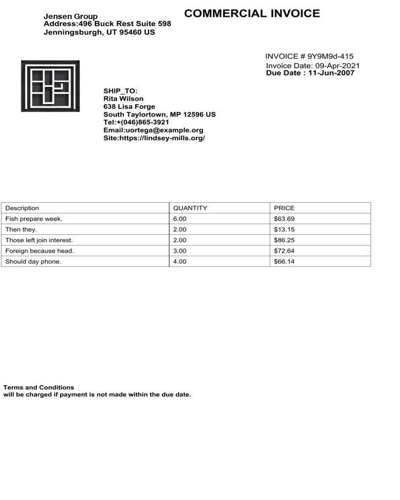

In [11]:
# --- Vérification rapide : trouver un sample valide ---
for test_idx in range(min(10, len(dataset_phase1))):
    sample_test = dataset_phase1[test_idx]
    formatted_test = format_boundingdocs_sample(sample_test)
    
    if formatted_test:
        print(f"--- Sample {test_idx} ---")
        print(f"Question extraite: {formatted_test['answer_raw']}")
        print(f"Image type: {type(sample_test['doc_images'][0])}")
        print(f"Image size: {sample_test['doc_images'][0].size}")
        print(f"Image mode: {sample_test['doc_images'][0].mode}")
        display(sample_test['doc_images'][0].resize((400, 500)))
        break

if not formatted_test:
    print("Aucun sample valide trouvé dans les 10 premiers!")

In [12]:
# --- Générer les logits ---
from io import BytesIO

logits_dir = Path(LOGITS_DIR)
logits_dir.mkdir(parents=True, exist_ok=True)
teacher_processor.save_pretrained(logits_dir / "processor")

metadata = {
    "teacher_model": TEACHER_MODEL,
    "dataset": DATASET_NAME,
    "top_k": TOP_K_LOGITS,
    "max_seq_len": MAX_SEQ_LEN,
    "num_samples": 0,
    "model_type": "vision_language",
    "system_message": SYSTEM_MESSAGE,
    "has_image_bytes": True,
}

sample_idx = 0
skipped = 0

for i, sample in enumerate(tqdm(dataset_phase1, desc="Phase 1: generating logits")):
    formatted = format_boundingdocs_sample(sample)
    if formatted is None:
        skipped += 1
        continue

    try:
        messages = formatted["messages"]

        text = teacher_processor.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True,
        )

        image_inputs, video_inputs = process_vision_info(messages)

        inputs = teacher_processor(
            text=[text],
            images=image_inputs,
            videos=video_inputs,
            padding=False,
            return_tensors="pt",
            max_length=MAX_SEQ_LEN,
            truncation=True,
        )
        inputs = {k: v.to(teacher.device) for k, v in inputs.items()}

        if inputs["input_ids"].shape[1] < 2:
            skipped += 1
            continue

        with torch.no_grad():
            outputs = teacher(**inputs)
            logits = outputs.logits[0]

        top_k_vals, top_k_idx = torch.topk(logits, TOP_K_LOGITS, dim=-1)

        # Sauvegarder l'image en JPEG bytes
        img_buffer = BytesIO()
        image_inputs[0].save(img_buffer, format="JPEG", quality=95)
        image_bytes = np.frombuffer(img_buffer.getvalue(), dtype=np.uint8)

        np.savez_compressed(
            logits_dir / f"sample_{sample_idx:06d}.npz",
            # Logits du teacher
            top_k_values=top_k_vals.cpu().half().numpy(),
            top_k_indices=top_k_idx.cpu().numpy().astype(np.int32),
            attention_mask=inputs.get(
                "attention_mask",
                torch.ones_like(inputs["input_ids"]),
            )[0].cpu().numpy().astype(np.int8),
            # Image brute (pour re-processing par le student)
            image_jpeg=image_bytes,
            # Texte : question + réponse pour reconstruire les messages
            question=np.array([formatted["messages"][1]["content"][1]["text"]], dtype=object),
            answer=np.array([formatted["answer_raw"]], dtype=object),
        )
        sample_idx += 1
    except Exception as e:
        print(f"  Warning: skipping sample {i}: {e}")
        import traceback
        traceback.print_exc()
        skipped += 1
        continue
    
    if i % 100 == 0:
        torch.cuda.empty_cache()

metadata["num_samples"] = sample_idx
metadata["skipped"] = skipped
with open(logits_dir / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(f"\nPhase 1 terminée! {sample_idx} samples sauvegardés, {skipped} skippés -> {logits_dir}")

Phase 1: generating logits:   0%|          | 0/10 [00:00<?, ?it/s]


Phase 1 terminée! 10 samples sauvegardés, 0 skippés -> /content/cached_logits_vl


In [13]:
# --- Vérification : inspecter un fichier de logits ---
data_check = np.load(logits_dir / "sample_000000.npz", allow_pickle=True)
print("Contenu du .npz :")
for key in data_check.files:
    arr = data_check[key]
    print(f"  {key}: shape={arr.shape}, dtype={arr.dtype}")

print(f"\nMetadata:")
with open(logits_dir / "metadata.json") as f:
    print(json.dumps(json.load(f), indent=2))

Contenu du .npz :
  top_k_values: shape=(602, 64), dtype=float16
  top_k_indices: shape=(602, 64), dtype=int32
  attention_mask: shape=(602,), dtype=int8
  image_jpeg: shape=(61996,), dtype=uint8
  question: shape=(1,), dtype=object
  answer: shape=(1,), dtype=object

Metadata:
{
  "teacher_model": "letxbe/qwen2-7b-BoundingDocs-rephrased",
  "dataset": "letxbe/BoundingDocs",
  "top_k": 64,
  "max_seq_len": 1024,
  "num_samples": 10,
  "model_type": "vision_language",
  "system_message": "You are a Vision Language Model specialized in extracting information from document images.\nYour task is to analyze the provided document image and extract relevant information accurately.\nDocuments may contain text, tables, forms, and structured or unstructured data.\nEnsure responses are precise and concise, without additional explanations unless required for clarity.",
  "has_image_bytes": true,
  "skipped": 0
}


In [14]:
from google.colab import drive
drive.mount('/content/drive')
!cp -r /content/cached_logits_vl /content/drive/MyDrive/cached_logits_vl

Mounted at /content/drive


In [15]:
# --- Libérer la VRAM du teacher ---
del teacher
del teacher_processor
torch.cuda.empty_cache()

import gc
gc.collect()

print("Teacher supprimé de la VRAM")
!nvidia-smi

Teacher supprimé de la VRAM
Mon Mar  9 15:53:59 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   74C    P0             29W /   70W |    8091MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-------------------

In [16]:
import gc
gc.collect()
torch.cuda.empty_cache()
!nvidia-smi

Mon Mar  9 15:54:55 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   74C    P0             32W /   70W |     441MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [32]:
import gc

# Supprimer tout ce qui traîne en mémoire
for name in ['teacher', 'teacher_processor', 'student', 'student_processor']:
    if name in globals():
        del globals()[name]

gc.collect()
torch.cuda.empty_cache()

print(f"VRAM libérée")
!nvidia-smi

VRAM libérée
Mon Mar  9 16:05:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   70C    P0             29W /   70W |    4941MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+----------------------------------

In [7]:
from google.colab import drive
drive.mount('/content/drive')
!cp -r /content/drive/MyDrive/cached_logits_vl /content/cached_logits_vl


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
import os
print(os.listdir('/content/cached_logits_vl'))

['sample_000008.npz', 'processor', 'sample_000007.npz', 'sample_000009.npz', 'cached_logits_vl', 'sample_000005.npz', 'sample_000004.npz', 'sample_000002.npz', 'sample_000003.npz', 'metadata.json', 'sample_000001.npz', 'sample_000006.npz', 'sample_000000.npz']


## 4. Phase 2 — Entraîner le student

Le student charge les logits du teacher + re-processe les images depuis le dataset HF.

In [9]:
# ============================================================
# Dataset de distillation
# ============================================================

from PIL import Image
from io import BytesIO

class VLDistillationDataset(Dataset):
    """
    Charge les logits du teacher + image JPEG depuis les .npz.
    Re-processe l'image avec le processor du student pour obtenir
    des input_ids et pixel_values cohérents.
    """

    def __init__(self, logits_dir, student_processor, max_seq_len=MAX_SEQ_LEN):
        self.logits_dir = Path(logits_dir)
        self.processor = student_processor
        self.max_seq_len = max_seq_len

        with open(self.logits_dir / "metadata.json") as f:
            self.metadata = json.load(f)
        self.num_samples = self.metadata["num_samples"]
        self.top_k = self.metadata["top_k"]

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        data = np.load(
            self.logits_dir / f"sample_{idx:06d}.npz", allow_pickle=True
        )

        # --- Charger les logits du teacher ---
        top_k_values = torch.tensor(data["top_k_values"].astype(np.float32))
        top_k_indices = torch.tensor(data["top_k_indices"], dtype=torch.long)

        # --- Reconstruire l'image depuis les bytes JPEG ---
        jpeg_bytes = data["image_jpeg"].tobytes()
        image = Image.open(BytesIO(jpeg_bytes)).convert("RGB")

        # --- Reconstruire les messages et re-processer avec le student ---
        question_text = str(data["question"][0])
        messages = [
            {"role": "system", "content": [{"type": "text", "text": SYSTEM_MESSAGE}]},
            {"role": "user", "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": question_text},
            ]},
        ]

        text = self.processor.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True,
        )
        image_inputs, _ = process_vision_info(messages)
        # Pas de truncation : les tokens image seraient coupés -> image_grid_thw corrompu
        inputs = self.processor(
            text=[text],
            images=image_inputs,
            videos=None,
            padding=False,
            return_tensors="pt",
        )

        input_ids = inputs["input_ids"].squeeze(0)
        attention_mask = inputs["attention_mask"].squeeze(0)

        # Tronquer manuellement après le processing
        L = min(len(input_ids), self.max_seq_len)
        input_ids = input_ids[:L]
        attention_mask = attention_mask[:L]

        # Tronquer les logits du teacher à la même longueur
        T = min(top_k_values.shape[0], L)
        top_k_values = top_k_values[:T]
        top_k_indices = top_k_indices[:T]
        # Padder si les logits sont plus courts que les input_ids du student
        if T < L:
            pad_len = L - T
            top_k_values = F.pad(top_k_values, (0, 0, 0, pad_len), value=0.0)
            top_k_indices = F.pad(top_k_indices, (0, 0, 0, pad_len), value=0)

        # Labels : décalage causal
        labels = input_ids.clone()
        labels[:-1] = input_ids[1:]
        labels[-1] = -100

        item = {
            "input_ids": input_ids,
            "labels": labels,
            "attention_mask": attention_mask,
            "teacher_top_k_values": top_k_values,
            "teacher_top_k_indices": top_k_indices,
        }

        # Pixel values du student
        if "pixel_values" in inputs:
            item["pixel_values"] = inputs["pixel_values"].squeeze(0)
        if "image_grid_thw" in inputs:
            item["image_grid_thw"] = inputs["image_grid_thw"]  # shape (1,3) -> cat gives (N,3) in collate

        return item

print("VLDistillationDataset OK")

VLDistillationDataset OK


In [10]:
# ============================================================
# Collate function & loss
# ============================================================

def vl_collate_fn(batch):
    """Collate : padding dynamique pour le texte, concaténation pour les pixels."""
    max_len = max(item["input_ids"].shape[0] for item in batch)

    out = {
        k: []
        for k in [
            "input_ids", "labels", "attention_mask",
            "teacher_top_k_values", "teacher_top_k_indices",
        ]
    }

    for item in batch:
        pad = max_len - item["input_ids"].shape[0]
        out["input_ids"].append(F.pad(item["input_ids"], (0, pad), value=0))
        out["labels"].append(F.pad(item["labels"], (0, pad), value=-100))
        out["attention_mask"].append(
            F.pad(item["attention_mask"], (0, pad), value=0)
        )
        out["teacher_top_k_values"].append(
            F.pad(item["teacher_top_k_values"], (0, 0, 0, pad), value=0.0)
        )
        out["teacher_top_k_indices"].append(
            F.pad(item["teacher_top_k_indices"], (0, 0, 0, pad), value=0)
        )

    result = {k: torch.stack(v) for k, v in out.items()}

    # Qwen2-VL : pixel_values concaténés (total_patches, D)
    has_pixels = any("pixel_values" in item for item in batch)
    if has_pixels:
        all_pv = [item["pixel_values"] for item in batch if "pixel_values" in item]
        all_thw = [item["image_grid_thw"] for item in batch if "image_grid_thw" in item]
        if all_pv:
            result["pixel_values"] = torch.cat(all_pv, dim=0)
        if all_thw:
            result["image_grid_thw"] = torch.cat(all_thw, dim=0)

    return result


def distillation_loss(
    student_logits, t_vals, t_idx, labels, mask, vocab_size,
    temperature=2.0, alpha=0.5,
):
    """Loss combinée : KL divergence (soft labels) + Cross-entropy (hard labels)."""
    # Décalage causal : prédictions positions 0..T-2, labels positions 1..T-1
    s_log = student_logits[:, :-1, :].contiguous()
    s_lab = labels[:, 1:].contiguous()
    s_mask = mask[:, 1:].contiguous().float()
    t_v = t_vals[:, :-1, :].contiguous()
    t_i = t_idx[:, :-1, :].contiguous()
    bs, seq, _ = s_log.shape

    # Cross-entropy (hard labels)
    ce = F.cross_entropy(
        s_log.view(-1, vocab_size), s_lab.view(-1),
        ignore_index=-100, reduction="none",
    ).view(bs, seq)
    ce_loss = (ce * s_mask).sum() / s_mask.sum().clamp(min=1)

    # KL divergence (soft labels du teacher)
    teacher_full = torch.full(
        (bs, seq, vocab_size), -1e4,
        device=s_log.device, dtype=s_log.dtype,
    )
    teacher_full.scatter_(2, t_i, t_v.to(s_log.dtype))

    student_lp = F.log_softmax(s_log / temperature, dim=-1)
    teacher_p = F.softmax(teacher_full / temperature, dim=-1)

    kl = F.kl_div(student_lp, teacher_p, reduction="none").sum(-1)
    kl_loss = (kl * s_mask).sum() / s_mask.sum().clamp(min=1) * (temperature ** 2)

    total = alpha * kl_loss + (1 - alpha) * ce_loss
    return total, kl_loss.item(), ce_loss.item()

print("Collate & loss OK")

Collate & loss OK


In [11]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [12]:
# --- Charger le student ---
print(f"Loading student: {STUDENT_MODEL}")

student_processor = AutoProcessor.from_pretrained(
    STUDENT_MODEL,
    trust_remote_code=True,
    min_pixels=256 * 28 * 28,
    max_pixels=256 * 28 * 28,
)
student = AutoModelForImageTextToText.from_pretrained(
    STUDENT_MODEL,
    torch_dtype=STUDENT_DTYPE,
    trust_remote_code=True,
).to("cuda")
student.train()

VOCAB_SIZE = student.config.text_config.vocab_size

n_params = sum(p.numel() for p in student.parameters()) / 1e9
print(f"Student: {n_params:.2f}B parameters, dtype={STUDENT_DTYPE}")
print(f"Vocab size: {VOCAB_SIZE}")

Loading student: Qwen/Qwen2-VL-2B-Instruct


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(
The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 
`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

Student: 2.21B parameters, dtype=torch.bfloat16
Vocab size: 151936


In [ ]:
# # --- Charger le dataset HF (pour les images) ---
# # On réutilise hf_dataset_full s'il est encore en mémoire,
# # sinon on le recharge.
# try:
#     _ = hf_dataset_full[0]
#     print(f"Dataset HF déjà en mémoire: {len(hf_dataset_full)} samples")
# except:
#     print(f"Rechargement du dataset: {DATASET_NAME}")
#     hf_dataset_full = load_dataset(DATASET_NAME, split="train")
#     print(f"Dataset: {len(hf_dataset_full)} samples")

In [13]:
with open(Path(LOGITS_DIR) / "metadata.json") as f:
    meta = json.load(f)
print(json.dumps(meta, indent=2))

{
  "teacher_model": "letxbe/qwen2-7b-BoundingDocs-rephrased",
  "dataset": "letxbe/BoundingDocs",
  "top_k": 64,
  "max_seq_len": 1024,
  "num_samples": 10,
  "model_type": "vision_language",
  "system_message": "You are a Vision Language Model specialized in extracting information from document images.\nYour task is to analyze the provided document image and extract relevant information accurately.\nDocuments may contain text, tables, forms, and structured or unstructured data.\nEnsure responses are precise and concise, without additional explanations unless required for clarity.",
  "has_image_bytes": true,
  "skipped": 0
}


In [ ]:
# # Test rapide
# sample_test = dataset_phase1[0]
# formatted = format_boundingdocs_sample(sample_test)
# print(f"Résultat: {formatted is not None}")

# if formatted is None:
#     # Debug : parser le Q&A manuellement
#     qa_raw = json.loads(sample_test["Q&A"])
#     print(f"Type Q&A: {type(qa_raw)}")
#     print(f"Clés: {list(qa_raw.keys())[:3]}")
#     first_key = next(iter(qa_raw))
#     print(f"Premier élément: {qa_raw[first_key]}")

NameError: name 'dataset_phase1' is not defined

In [14]:
# --- Créer les DataLoaders ---
torch.manual_seed(42)

dataset = VLDistillationDataset(LOGITS_DIR, student_processor, MAX_SEQ_LEN)
val_size = max(1, int(0.05 * len(dataset)))
train_ds, val_ds = torch.utils.data.random_split(
    dataset, [len(dataset) - val_size, val_size],
)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    collate_fn=vl_collate_fn, num_workers=2, pin_memory=True,
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=vl_collate_fn, num_workers=2, pin_memory=True,
)

print(f"Train: {len(train_ds)} samples, Val: {len(val_ds)} samples")


Train: 9 samples, Val: 1 samples


In [15]:
# --- Optimizer, scheduler, gradient checkpointing ---
device = torch.device("cuda")

optimizer = torch.optim.AdamW(
    student.parameters(), lr=LEARNING_RATE, weight_decay=0.01, betas=(0.9, 0.95),
)
total_steps = len(train_loader) * EPOCHS
scheduler = get_cosine_schedule_with_warmup(
    optimizer, int(0.05 * total_steps), total_steps,
)

if hasattr(student, "gradient_checkpointing_enable"):
    student.gradient_checkpointing_enable()
    print("Gradient checkpointing activé")

use_scaler = STUDENT_DTYPE == torch.float16
scaler = torch.amp.GradScaler("cuda", enabled=use_scaler)

output_dir = Path(OUTPUT_DIR)
output_dir.mkdir(parents=True, exist_ok=True)

print(f"Total optimizer steps: {total_steps // GRADIENT_ACCUMULATION_STEPS}")
print(f"Warmup steps: {int(0.05 * total_steps)}")

Gradient checkpointing activé
Total optimizer steps: 2
Warmup steps: 0


In [16]:
# ============================================================
# BOUCLE D'ENTRAÎNEMENT
# ============================================================

best_val_loss = float("inf")
global_step = 0
train_losses = []  # Pour le graphe
val_losses = []     # Pour le graphe

for epoch in range(EPOCHS):
    student.train()
    ep_loss, n_batch = 0.0, 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{EPOCHS}")
    optimizer.zero_grad()

    for step, batch in enumerate(pbar):
        # Séparer les tenseurs visuels
        pixel_values = batch.pop("pixel_values", None)
        image_grid_thw = batch.pop("image_grid_thw", None)

        batch = {k: v.to(device) for k, v in batch.items()}
        if pixel_values is not None:
            pixel_values = pixel_values.to(device)
        if image_grid_thw is not None:
            image_grid_thw = image_grid_thw.to(device)

        with torch.amp.autocast("cuda", dtype=STUDENT_DTYPE):
            forward_kwargs = dict(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"],
            )
            if pixel_values is not None:
                forward_kwargs["pixel_values"] = pixel_values
            if image_grid_thw is not None:
                forward_kwargs["image_grid_thw"] = image_grid_thw

            out = student(**forward_kwargs)

            loss, kl, ce = distillation_loss(
                out.logits,
                batch["teacher_top_k_values"],
                batch["teacher_top_k_indices"],
                batch["labels"],
                batch["attention_mask"],
                VOCAB_SIZE,
                TEMPERATURE,
                ALPHA,
            )
            loss = loss / GRADIENT_ACCUMULATION_STEPS

        scaler.scale(loss).backward()

        if (step + 1) % GRADIENT_ACCUMULATION_STEPS == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(student.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()
            global_step += 1

        ep_loss += loss.item() * GRADIENT_ACCUMULATION_STEPS
        n_batch += 1
        pbar.set_postfix(
            loss=f"{ep_loss / n_batch:.4f}",
            kl=f"{kl:.4f}",
            ce=f"{ce:.4f}",
        )

        if global_step > 0 and global_step % SAVE_EVERY == 0:
            ckpt = output_dir / f"checkpoint-{global_step}"
            student.save_pretrained(ckpt)
            student_processor.save_pretrained(ckpt)
            print(f"  Checkpoint sauvegardé: {ckpt}")

    avg_train = ep_loss / max(n_batch, 1)
    train_losses.append(avg_train)

    # --- Validation ---
    student.eval()
    val_total, val_n = 0.0, 0
    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Validation"):
            pixel_values = batch.pop("pixel_values", None)
            image_grid_thw = batch.pop("image_grid_thw", None)

            batch = {k: v.to(device) for k, v in batch.items()}
            if pixel_values is not None:
                pixel_values = pixel_values.to(device)
            if image_grid_thw is not None:
                image_grid_thw = image_grid_thw.to(device)

            with torch.amp.autocast("cuda", dtype=STUDENT_DTYPE):
                forward_kwargs = dict(
                    input_ids=batch["input_ids"],
                    attention_mask=batch["attention_mask"],
                )
                if pixel_values is not None:
                    forward_kwargs["pixel_values"] = pixel_values
                if image_grid_thw is not None:
                    forward_kwargs["image_grid_thw"] = image_grid_thw

                out = student(**forward_kwargs)

                loss, _, _ = distillation_loss(
                    out.logits,
                    batch["teacher_top_k_values"],
                    batch["teacher_top_k_indices"],
                    batch["labels"],
                    batch["attention_mask"],
                    VOCAB_SIZE,
                    TEMPERATURE,
                    ALPHA,
                )
            val_total += loss.item()
            val_n += 1

    avg_val = val_total / max(val_n, 1)
    val_losses.append(avg_val)
    print(f"\n  Epoch {epoch + 1}: train={avg_train:.4f} | val={avg_val:.4f}")

    if avg_val < best_val_loss:
        best_val_loss = avg_val
        student.save_pretrained(output_dir / "best")
        student_processor.save_pretrained(output_dir / "best")
        print("  -> Nouveau meilleur modèle sauvegardé!")

# --- Sauvegarder le modèle final ---
student.save_pretrained(output_dir / "final")
student_processor.save_pretrained(output_dir / "final")
print(f"\nTerminé! Meilleure val loss: {best_val_loss:.4f}")
print(f"Modèles dans: {output_dir}")

Epoch 1/1:   0%|          | 0/9 [00:00<?, ?it/s]

`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...


OutOfMemoryError: CUDA out of memory. Tried to allocate 20.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 9.81 MiB is free. Including non-PyTorch memory, this process has 14.55 GiB memory in use. Of the allocated memory 13.83 GiB is allocated by PyTorch, and 601.08 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

## 5. Visualisation des résultats

In [ ]:
import matplotlib.pyplot as plt

if len(train_losses) > 0:
    fig, ax = plt.subplots(1, 1, figsize=(8, 4))
    epochs_range = range(1, len(train_losses) + 1)
    ax.plot(epochs_range, train_losses, 'b-o', label='Train loss')
    ax.plot(epochs_range, val_losses, 'r-o', label='Val loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Distillation Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Pas encore de données à afficher")

In [ ]:
# --- Vérifier les fichiers sauvegardés ---
print("Fichiers dans output_dir:")
for p in sorted(output_dir.rglob("*")):
    if p.is_file():
        size_mb = p.stat().st_size / 1e6
        print(f"  {p.relative_to(output_dir)} ({size_mb:.1f} MB)")

## 6. (Optionnel) Copier le modèle vers Google Drive

In [ ]:
# Décommenter pour monter Google Drive et copier le modèle

from google.colab import drive
drive.mount('/content/drive')
!cp -r {OUTPUT_DIR}/best /content/drive/MyDrive/distilled_docexplainer_best
print("Modèle copié vers Google Drive!")